# Homework \#9

Camera Calibration and Undistortion




## Import Modules

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import scipy.linalg
import mae6292.tools as mae6292
import importlib
import glob

from mae6292.imshow import cv2_imshow
from mae6292.undistort import undistort_and_resize

## Camera Calibration - Revisited

We covered camera calibration at HW#2 using a single image of a checker board. Here we extend it into calibration with multiple images of a checker board, which should improve the accuracy of calibration.

The 8 by 6 checkerboard file (`checkerboard-A4-25mm-8x6.pdf`) was printed on a letter paper, and 5 images were taken from varying perspectives, which are saved into `data/IMG*.png`.

The following code detects corners for each image file and save the results into `corners_list`.


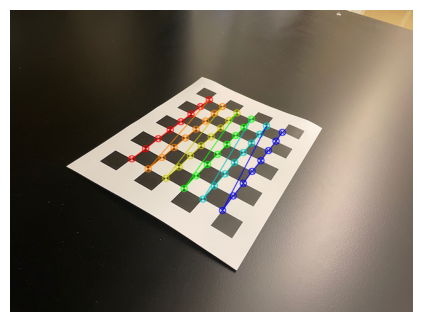

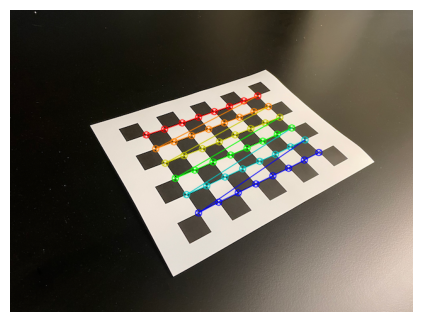

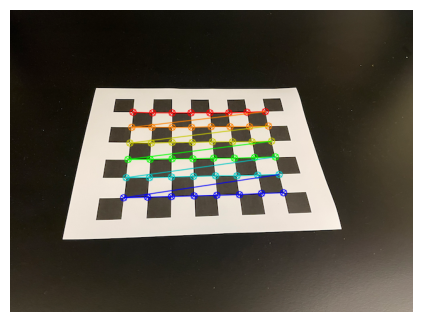

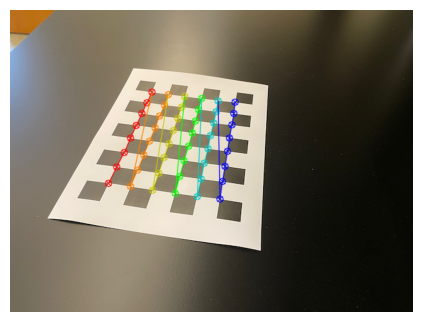

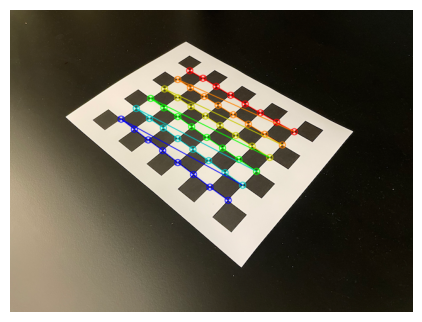

In [5]:
CHECKER = (8,6)
CHECKER_WIDTH = 1

obj_points = np.zeros( (CHECKER[0] * CHECKER[1], 1, 3 ), np.float32)
for i in range(CHECKER[1]):
    for j in range(CHECKER[0]):
         obj_points[i*CHECKER[0]+j,0,:]=np.array([[j,i,0]])
obj_points *= CHECKER_WIDTH

obj_points_list = []
corners_list = [] 

criteria_subpix = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

files = glob.glob('data/*.png')
for file in files:
    img = cv2.imread(file)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    flag_found, corners = cv2.findChessboardCorners(img_gray, CHECKER)

    if flag_found == True:
        obj_points_list.append(obj_points)
        corners_refined = cv2.cornerSubPix(img_gray, corners, (11,11), (-1,-1), criteria_subpix)
        corners_list.append(corners_refined)
        
        img_corner = img.copy()
        cv2.drawChessboardCorners(img_corner, CHECKER, corners, flag_found)
        cv2_imshow(img_corner, dpi = 100)


For the dectected corners, the calibration matrix and the distortion coefficients are obtained by

In [3]:
err, K, dist_coeff, rvecs, tvecs = cv2.calibrateCamera(obj_points_list, corners_list, img_gray.shape[::-1], None, None)

print('K=', K)
print('dist_coeff=', dist_coeff)

K= [[503.01052926   0.         324.20805919]
 [  0.         499.59641948 205.00799583]
 [  0.           0.           1.        ]]
dist_coeff= [[ 0.19293611 -0.55881758 -0.03327754  0.00496538  1.19593208]]


## Distortion 

As shown above, in addition to the calibration matrix, we obtain the coefficients for lens distortion, which can be used to undistort any image as follows. 

We took a sample image with the same camera, and it is saved into `data/sample.png`. The following code undistort it with the above coefficients. It is composed of two steps of refining the calibration matrix and using [`cv2.undistort()`](https://docs.opencv.org/3.4/da/d54/group__imgproc__transform.html#ga69f2545a8b62a6b0fc2ee060dc30559d).

See [here](https://docs.opencv.org/3.4/dc/dbb/tutorial_py_calibration.html) for the detailed description. 

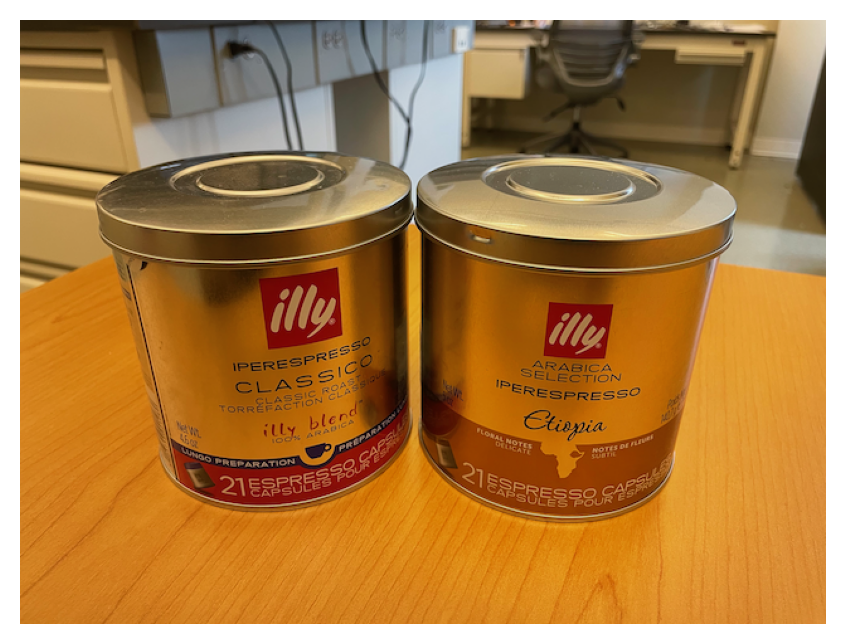

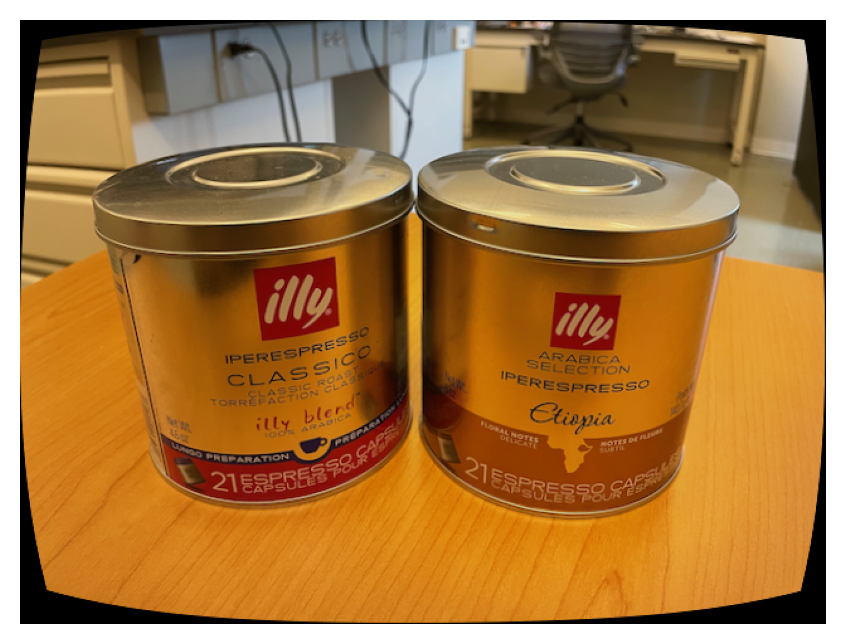

In [6]:
img = cv2.imread('data/sample.png')

h,  w = img.shape[:2]
K_opt, ROI =cv2.getOptimalNewCameraMatrix(K, dist_coeff, (w,h), 1, (w,h))
img_undist = cv2.undistort(img, K, dist_coeff, None, K_opt)

# crop the image
# x,y,w,h = ROI
# img_undist = img_undist[y:y+h, x:x+w]

cv2.imwrite('data/undist.png',img_undist)

cv2_imshow(img)
cv2_imshow(img_undist)

## Problem 1

In this assignment, we use the above results to take a video by ourselves and undistort it, as a prelmimary step of the course project. 

First, we will calibrate our camera as follows.

1.  Print the chessboard image `checkerboard-A4-25mm-8x6.pdf`
2.  Take a video of the checkerboard while moving your camera, save it into `prob1.mp4`
3.  Extract frames from your video, and save every frame to the folder `calib/`. See [here](https://theailearner.com/2018/10/15/extracting-and-saving-video-frames-using-opencv-python/) for extracting frames from a video.
4.  Calibrate your camera by following the codes in the above **Camera Calibration** section.
5.  Print your `K` and `dist_coeff`

At Step 3, if your extracted image has higher-resolution, it is recommended to reduce it into the level of 640 x 480 approximately. See [here](https://pythonexamples.org/python-opencv-cv2-resize-image/) for an example of `cv2.resize()`.

Make it sure that the image resizing is completed **before** calibrating your camera, as the calibration matrix $K$ is affected by resizing.

State your camera model and print out the calibration matrix and the distortion coefficients.

**ANSWER** My camera is ....

In [ ]:




print('K=', K)
print('dist_coeff=', dist_coeff)

## Problem 2

Next, we will take a video of any scene for about 10 seconds, and we will create an undistorted video from the above calibration. This is completed by

1.  Using the same camera, take a video of any dynamic scene for about 10 seconds, and save it into `prob2.mp4`.
2.  Extract frames from your video, and save every frame to the folder `prob2/`
3.  Undistort each frame and save it to the folder `prob2_undistort/`
4.  Create a video from your undistorted images, and save it into `prob2_undistort.mp4`. See [here](https://theailearner.com/2018/10/15/creating-video-from-images-using-opencv-python/) for creatinv a video from images. It is recommended to use the video codec `cv2.VideoWriter_fourcc(*'mp4v')`




### How To Submit

Attach

1.  `prob1.mp4`
2.  `prob2.mp4`, `prob2_undistort.mp4`